In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
pd.set_option('display.max_columns', None)

all_df = pd.DataFrame()

for i in range(2024, 2012, -1):
    df = pd.read_csv(Path.cwd() / "data" / str(i) / "hitters_individual.csv")
    df['year'] = i
    all_df = pd.concat([all_df, df], axis=0, ignore_index=True)

all_data = all_df.copy()

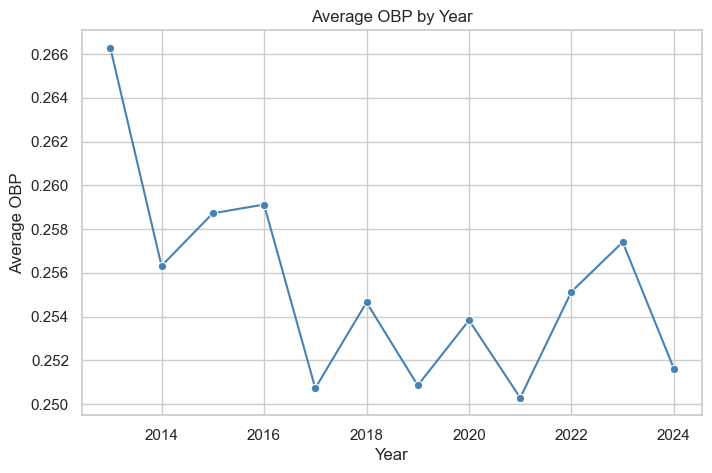

In [290]:
obp_by_year = all_df.groupby("year")['obp'].mean()
plt.figure(figsize=(8,5))

sns.set_theme(style="whitegrid")  # Other options: darkgrid, ticks, white, etc.
sns.lineplot(x=obp_by_year.index, y=obp_by_year.values, marker='o', color='steelblue')
plt.title("Average OBP by Year")
plt.xlabel("Year")
plt.ylabel("Average OBP")
plt.show()

# plt.savefig("average_OBP_time_series.png", dpi=300, bbox_inches='tight')  # PNG format, high resolution

In [291]:
# all_df.to_excel('output.xlsx', index=False)


In [292]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                3655 non-null   int64  
 1   id                        3655 non-null   int64  
 2   first_name                3655 non-null   object 
 3   last_name                 3655 non-null   object 
 4   current_team              3655 non-null   object 
 5   position                  3655 non-null   object 
 6   mlb_debut                 3655 non-null   object 
 7   bat_side                  3655 non-null   object 
 8   pitch_hand                3655 non-null   object 
 9   type                      3655 non-null   object 
 10  group                     3655 non-null   object 
 11  season                    3655 non-null   int64  
 12  age                       3219 non-null   float64
 13  gamesPlayed               3655 non-null   int64  
 14  groundOu

In [293]:
all_df.drop(
    ["Unnamed: 0", "id", "first_name", "last_name", "current_team",
     "stolenBasePercentage", "caughtStealingPercentage",
     "atBatsPerHomeRun", "position", "mlb_debut", "type", "babip",
     "groundOutsToAirouts", "group", "bat_side", "pitch_hand", "season"],
    axis=1,
    inplace=True
)

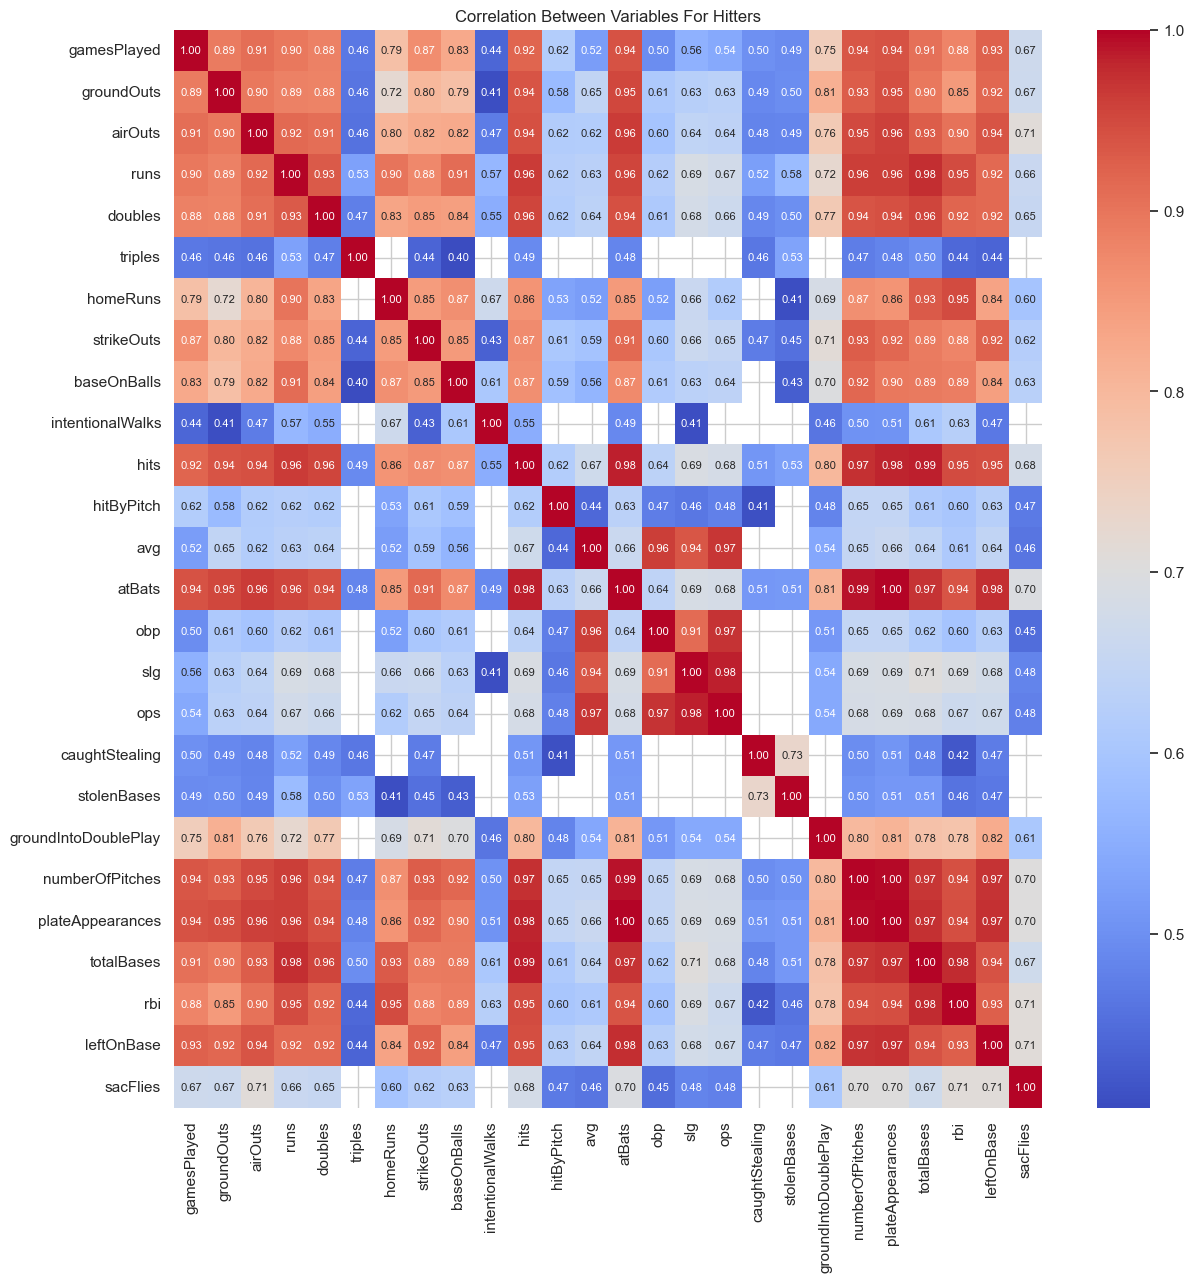

In [294]:

threshold = 0.4
correlation = all_df.corr()
filtered_corr = correlation.where(abs(correlation) >= threshold)
filtered_corr = filtered_corr.drop(["age", "sacBunts", "catchersInterference", "year"], axis=1)
filtered_corr = filtered_corr.drop(["age", "sacBunts", "catchersInterference", "year"], axis=0)



plt.figure(figsize=(14,14))

sns.heatmap(filtered_corr, 
            annot=True, 
            fmt='.2f', 
            cmap="coolwarm", 
            annot_kws={"size": 8})
sns.set_theme(style="whitegrid")
plt.title("Correlation Between Variables For Hitters")

plt.show()
# plt.savefig("Correlation.png", dpi=300, bbox_inches='tight')  # PNG format, high resolution

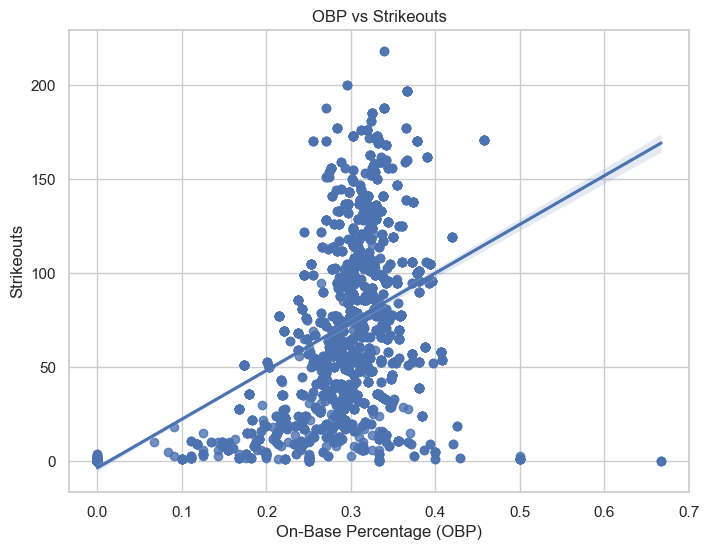

<Figure size 640x480 with 0 Axes>

In [295]:
# OBP & Strikeouts

sns.set_theme(style="whitegrid")  # optional theme
plt.figure(figsize=(8,6))

sns.regplot(x="obp", y='strikeOuts', data=all_df)
plt.title("OBP vs Strikeouts")
plt.xlabel("On-Base Percentage (OBP)")
plt.ylabel("Strikeouts")
plt.show()
plt.savefig("obp_strikeouts.png", dpi=300, bbox_inches='tight')  # PNG format, high resolution

In [296]:
all_data.columns

Index(['Unnamed: 0', 'id', 'first_name', 'last_name', 'current_team',
       'position', 'mlb_debut', 'bat_side', 'pitch_hand', 'type', 'group',
       'season', 'age', 'gamesPlayed', 'groundOuts', 'airOuts', 'runs',
       'doubles', 'triples', 'homeRuns', 'strikeOuts', 'baseOnBalls',
       'intentionalWalks', 'hits', 'hitByPitch', 'avg', 'atBats', 'obp', 'slg',
       'ops', 'caughtStealing', 'stolenBases', 'stolenBasePercentage',
       'caughtStealingPercentage', 'groundIntoDoublePlay', 'numberOfPitches',
       'plateAppearances', 'totalBases', 'rbi', 'leftOnBase', 'sacBunts',
       'sacFlies', 'babip', 'groundOutsToAirouts', 'catchersInterference',
       'atBatsPerHomeRun', 'year'],
      dtype='object')

In [297]:
obp_corr = filtered_corr['obp'] 
obp_corr = pd.DataFrame(obp_corr)
obp_corr.drop(['triples', "caughtStealing", "stolenBases", 'intentionalWalks'], inplace=True)

/var/folders/0_/_3dg0b615p38ptjrygv5db6h0000gn/T/ipykernel_30374/2760055155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


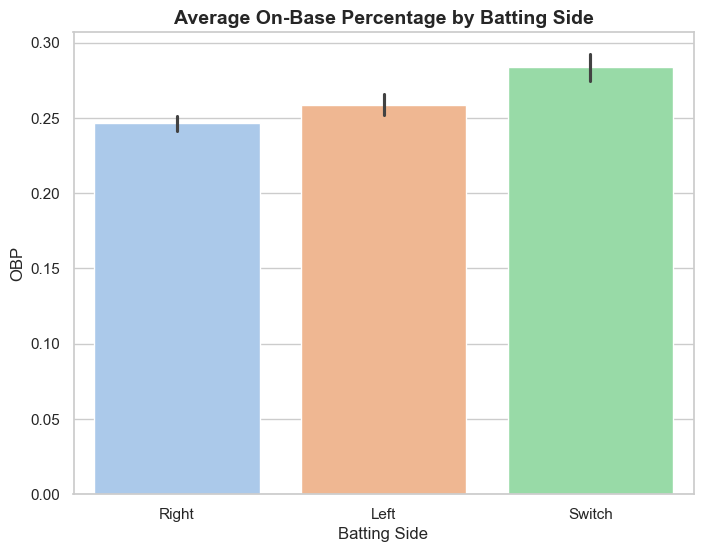

In [298]:

plt.figure(figsize=(8, 6))
sns.barplot(
    x='bat_side', 
    y='obp', 
    data=all_data, 
    palette='pastel'
    )

plt.title('Average On-Base Percentage by Batting Side', fontsize=14, weight='bold')
plt.xlabel('Batting Side', fontsize=12)
plt.ylabel('OBP', fontsize=12)

plt.show()
# plt.savefig("Batting side.png", dpi=300, bbox_inches='tight')  # PNG format, high resolution

/var/folders/0_/_3dg0b615p38ptjrygv5db6h0000gn/T/ipykernel_30374/89478888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


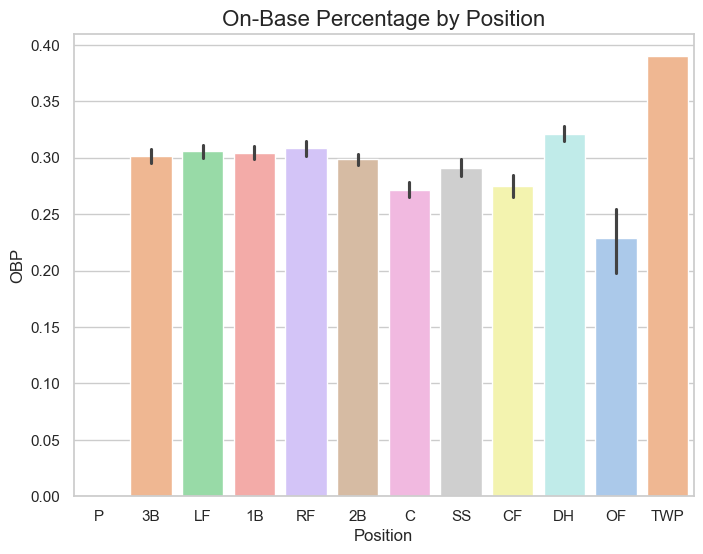

In [299]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='position', 
    y='obp', 
    data=all_data, 
    palette='pastel')

plt.title("On-Base Percentage by Position", fontsize=16)

plt.xlabel("Position")
plt.ylabel("OBP")

plt.show()
# plt.savefig("Position side.png", dpi=300, bbox_inches='tight') 

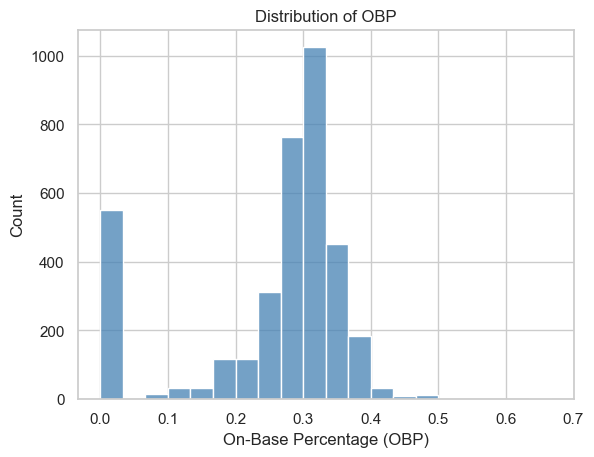

In [300]:
sns.histplot(x="obp", data=all_data, bins=20, kde=False, color='steelblue')
plt.title("Distribution of OBP")
plt.xlabel("On-Base Percentage (OBP)")
plt.ylabel("Count")
plt.show()
# plt.savefig("OBP Distribution.png", dpi=300, bbox_inches='tight') 

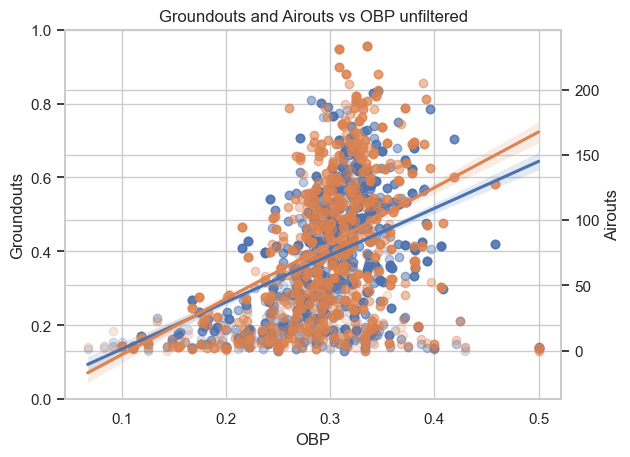

<Figure size 640x480 with 0 Axes>

In [317]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.regplot(x='obp', y='groundOuts', data=all_df, scatter_kws={"alpha":0.2})
sns.regplot(x='obp', y='airOuts', data=all_df, scatter_kws={"alpha":0.2})
ax1.set_xlabel('OBP')
ax1.set_ylabel('Groundouts')
ax2.set_ylabel('Airouts')
plt.title('Groundouts and Airouts vs OBP unfiltered')
plt.show()
plt.savefig("Outs & OBP.png", dpi=300, bbox_inches='tight') 

# Handling Outlier

In [ ]:
all_df_filtered = all_df[(all_df['obp'] < 0.6) & (all_df['obp'] > 0.05)]

,age,gamesPlayed,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,caughtStealing,stolenBases,groundIntoDoublePlay,numberOfPitches,plateAppearances,totalBases,rbi,leftOnBase,sacBunts,sacFlies,catchersInterference,year
1,27.0,110,82,118,63,26,2,19,118,37,0,109,5,0.256,425,0.322,0.461,0.783,0,0,6,1822,469,196,56,175,0,2,0,2024
2,27.0,12,3,3,4,0,0,1,4,0,0,2,0,0.167,12,0.167,0.417,0.584,0,2,0,46,12,5,1,4,0,0,0,2024
3,27.0,21,10,14,3,1,1,2,11,7,0,7,0,0.175,40,0.286,0.400,0.686,0,1,1,201,49,16,10,21,0,2,0,2024
4,27.0,51,36,22,5,3,0,0,10,4,0,19,3,0.221,86,0.280,0.256,0.536,0,1,2,358,94,22,10,48,1,0,0,2024
5,27.0,112,83,93,59,17,0,15,89,40,1,92,3,0.259,355,0.338,0.434,0.772,1,4,12,1576,400,154,52,141,0,2,0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,31.0,145,114,144,85,42,0,30,138,76,11,157,2,0.285,550,0.373,0.525,0.898,4,7,18,2469,631,289,87,213,1,2,0,2013
3650,34.0,153,153,171,94,31,0,20,119,47,2,185,7,0.295,628,0.350,0.439,0.789,7,22,15,2454,682,276,65,193,0,0,0,2013
3651,37.0,120,97,116,66,18,1,20,133,58,1,104,7,0.232,448,0.328,0.411,0.739,2,3,9,2163,515,184,50,169,0,2,0,2013
3652,NaN,139,94,159,59,24,0,11,95,59,2,119,13,0.259,460,0.354,0.383,0.737,2,0,16,2320,539,176,55,208,0,7,0,2013


# Better Graphs

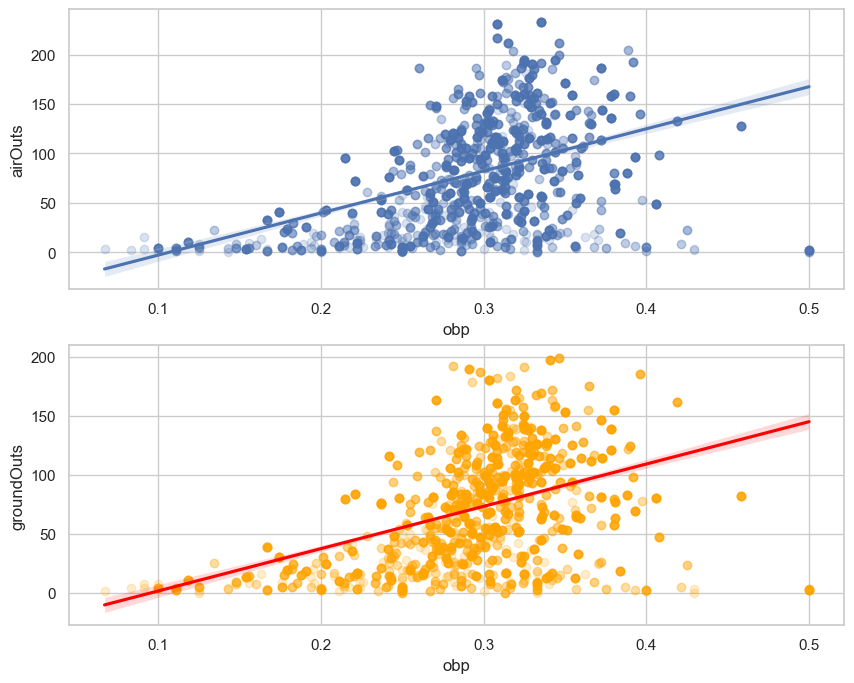

In [ ]:
plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
sns.regplot(x='obp', y='airOuts', data=all_df_filtered, scatter_kws={"alpha":0.2})

plt.subplot(2,1,2)
sns.regplot(x='obp', 
            y='groundOuts', 
            data=all_df_filtered, 
            scatter_kws={"alpha":0.2, "color":'orange'},
            line_kws={'color':'red'})

plt.show()
